# Part 1 ConvNet for small dataset

Having to train an image classification model using very little data is a common situation, which you’ll likely encounter in practice if you ever do computer vision in a professional context. A “few” samples can mean anywhere from a few hundred to a few tens of thousands of images. As a practical example, we’ll focus on classifying images as dogs or cats, in a dataset containing 4,000 pictures of cats and dogs (2,000 cats, 2,000 dogs). We’ll use 2,000 pictures for training – 1,000 for validation, and 1,000 for testing.

# Dataset


This original dataset contains 25,000 images of dogs and cats (12,500 from each class) and is ~800MB large (compressed). However, to simulate the real case of having a limited numeber of images we will only use 4,000.


You can download the whole dataset from Kaggle: https://www.kaggle.com/c/dogs-vs-cats/data or a subset of 4,000 from my Google Drive
https://drive.google.com/file/d/18PsGch7egeczC4zLjYw3dXGjHyL-Kebw/view?usp=sharing

However, if you are using Google Colab and don't want to download the whole dataset on your computer, you can load them directly into a temporary Colab memory using commands below. It will save you time and memory, but you will have to run this every time.



```
! gdown --id 18PsGch7egeczC4zLjYw3dXGjHyL-Kebw
! unzip /content/dataset_cats_dogs.zip
```

After downloading the data, you have to arrange them correctly in the catalogues. Data should be split into separate catalogs for dogs and for cats. You can do it manually or in python (for example using os and shutil libraries).

```
main_directory/
...train/
......class_a/
.........a_image_1.jpg
.........a_image_2.jpg
......class_b/
.........b_image_1.jpg
.........b_image_2.jpg
...validation/
......class_a/
.........a_image_1.jpg
.........a_image_2.jpg
......class_b/
.........b_image_1.jpg
.........b_image_2.jpg
```


Please check the train/validation/test datasets. We now have 2000 training images, then 1000 validation images and 1000 test images (optional). In each split, there is the same number of samples from each class: this is a balanced binary classification problem, which means that classification accuracy will be an appropriate measure of success.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Link your personal Google Drive or load images directly using gdown
# Split the images into folder manualy or write a code that does that
base_path = 'drive/MyDrive/msi4_Klasyfikacja_Obrazów/dataset'

# Network architecture

You've already built a small convnet for MNIST in the previous exercise. You will reuse the same general structure: our convnet will be a stack of alternated Conv2D (with relu activation) and MaxPooling2D layers.

However, since we are dealing with bigger images and a more complex problem, we will make our network larger: it will have one more Conv2D + MaxPooling2D stage. Here, since we start from inputs of size 150×150 (a somewhat arbitrary choice), we end up with feature maps of size 7×7 right before the Flatten layer. Note that the depth of the feature maps is progressively increasing in the network (from 32 to 128), while the size of the feature maps is decreasing (from 148×148 to 7×7). This is a pattern that you will see in almost all convnets. Since we are attacking a binary classification problem, we are ending the network with a single unit (a Dense layer of size 1) and a sigmoid activation. This unit will encode the probability that the network is looking at one class or the other.

Please create your network architecture based on the information above (4x Conv2d, 4x Maxpooling layers and then Flatten, 2 x Dense layer).

In [ ]:
# Configure the model to look like the following summary
from keras import models
from keras import layers

model = models.Sequential()
model.add(layers.Rescaling(1./255, input_shape=(150, 150, 3)))
model.add(layers.Conv2D(32, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))



```

Layer (type)                 Output Shape              Param #   
=================================================================
rescaling_1 (Rescaling)     (None, 150, 150, 3)       0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 148, 148, 32)      896       
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 74, 74, 32)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 72, 72, 64)        18496     
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 36, 36, 64)        0         
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 34, 34, 128)       73856     
_________________________________________________________________
max_pooling2d_3 (MaxPooling2 (None, 17, 17, 128)       0         
_________________________________________________________________
conv2d_4 (Conv2D)            (None, 15, 15, 128)       147584    
_________________________________________________________________
max_pooling2d_4 (MaxPooling2 (None, 7, 7, 128)         0         
_________________________________________________________________
flatten_1 (Flatten)          (None, 6272)              0         
_________________________________________________________________
dense_1 (Dense)              (None, 512)               3211776   
_________________________________________________________________
dense_2 (Dense)              (None, 1)                 513       
=================================================================
Total params: 3,453,121
Trainable params: 3,453,121
Non-trainable params: 0
__________________________

```



Compilation step:

* RMSprop optimizer - with learning rate parameter(lr=1e-4)
* Binary crossentropy loss funtion
* Accuracy metric


In [ ]:
# Compile the model

model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Data preprocessing

Data preprocessing steps include the following:

* Read the picture files.
* Decode the JPEG content to RBG grids of pixels.
* Convert these into floating-point tensors.
* Rescale the pixel values (between 0 and 255) to the [0, 1] interval (as you know, neural networks prefer to deal with small input values).

It may seem a bit daunting, but thankfully Keras has utilities to take care of these steps automatically. It has a module with image processing helper tools, located at `tensorflow.keras.preprocessing`. A function called `image_dataset_from_directory` allows to automatically turn image files on disk into batches of pre-processed tensors. One of the useful properties is the ability to automatically label data based on which folder they are in. That is why, at the beginning of the exercise, we put dogs and cats into the appropriate folders.

*Trivia: In older versions of the library we used to work with `ImageDataGenerator` Class to load images. You may still find it in many tutorials. It is a very nice tool with many additional features (such as data augmentation), but you will need older tensorflow and keras version for that.*

In [ ]:
from tensorflow.keras.preprocessing import  image_dataset_from_directory

train_dir = base_path + "/train"
val_dir = base_path + "/validate"
test_dir = base_path + "/test"


train_dataset = image_dataset_from_directory(
    train_dir,  # This is the target directory
    labels="inferred",
    label_mode="binary", # Since we use binary_crossentropy loss, we need binary labels
    class_names=None,
    color_mode="rgb",
    batch_size=20,
    image_size=(150,150), # All images have different sizes and will be resized to 150x150
    shuffle=True,
)

val_dataset = image_dataset_from_directory(
    val_dir,  # This is the target directory
    labels="inferred",
    label_mode="binary", # Since we use binary_crossentropy loss, we need binary labels
    class_names=None,
    color_mode="rgb",
    batch_size=20,
    image_size=(150,150), # All images have different sizes and will be resized to 150x150
    shuffle=True,
)

test_dataset = image_dataset_from_directory(
    test_dir,  # This is the target directory
    labels="inferred",
    label_mode="binary", # Since we use binary_crossentropy loss, we need binary labels
    class_names=None,
    color_mode="rgb",
    batch_size=20,
    image_size=(150,150), # All images have different sizes and will be resized to 150x150
    shuffle=True,
)

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.


In [ ]:
history = model.fit(train_dataset, epochs=30, validation_data=val_dataset)

Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 151ms/step - accuracy: 0.4905 - loss: 0.7135 - val_accuracy: 0.5620 - val_loss: 0.6925
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 106ms/step - accuracy: 0.5260 - loss: 0.6945 - val_accuracy: 0.5000 - val_loss: 0.6890
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 119ms/step - accuracy: 0.5575 - loss: 0.6912 - val_accuracy: 0.6400 - val_loss: 0.6634
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 124ms/step - accuracy: 0.6265 - loss: 0.6626 - val_accuracy: 0.6600 - val_loss: 0.6321
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 109ms/step - accuracy: 0.6795 - loss: 0.6046 - val_accuracy: 0.6640 - val_loss: 0.6010
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 110ms/step - accuracy: 0.7270 - loss: 0.5580 - val_accuracy: 0.6600 - val_loss: 0.6316
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 116ms/step - accuracy: 0.7335 - loss: 0.5252 - val_accuracy: 0.7040 - val_loss: 0.5734
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 128ms/step - accuracy: 0.7805 - loss: 0

# Outcome analysis

 Plot the loss and accuracy of the model over the training and validation data during training.

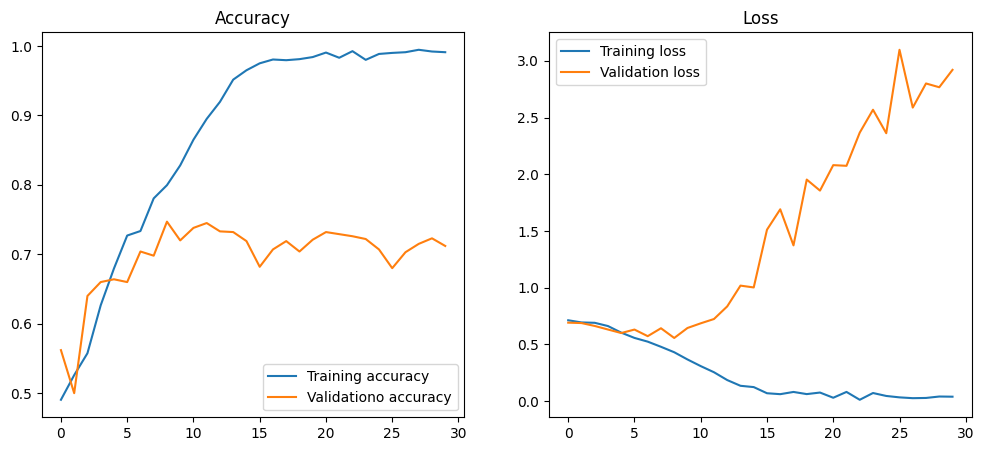

In [ ]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training accuracy')
plt.plot(epochs_range, val_acc, label='Validation accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training loss')
plt.plot(epochs_range, val_loss, label='Validation loss')
plt.title('Loss')
plt.legend()

plt.show()


 In these plots, you should see that the model is overfitting. Our training accuracy increases linearly over time, until it reaches nearly 100%, while our validation accuracy stalls at 70-72%. Our validation loss reaches its minimum after only five epochs then stalls, while the training loss keeps decreasing linearly until it reaches nearly 0.

Because we only have relatively few training samples (2000), overfitting is going to be our number one concern. There are many techniques that can help mitigate overfitting, such as reducing the number of epochs, adding dropout layers dropout, or weight decay (L2 regularization). We will look at them in the next task.

# Part 2 Data augmentation

Data augmentation takes the approach of generating more training data from existing training samples, by “augmenting” the samples via a number of random transformations that yield believable-looking images. The common-sense approach would be the manual creation of more images and applying small changes. However, it can be done easier and more efficiently in Keras.

The goal is that at training time, our model would never see the exact same picture twice. It will change each image at the loading stage. This helps the model get exposed to more aspects of the data and generalize better. Below you can see an example.

In [ ]:
#Create data augmentation as a separate model

data_augmentation = models.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.RandomTranslation(0.1, 0.1),
    ]
)

# Nest data augmentation model as a layer

model = models.Sequential()

model.add(data_augmentation)

# Create a full modell based on the above example. Use previous model and add augmentation.
model.add(layers.Rescaling(1./255, input_shape=(150, 150, 3)))
model.add(layers.Conv2D(32, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

If we train a new network using this data augmentation configuration, our network will never see twice the same input. However, the inputs that it sees are still heavily intercorrelated, since they come from a small number of original images, so the results won't be that much better.

Set parameters of the data augmentation yourself. We tested the values of rotations and zooms at about 0,2 but you can experiment with those.

Train the network using data augmentation. Note, that this time we train the network longer (**for about 100 epochs**) and it still increases. If training takes too much time on your machine, you can try lower numbers. After 100 epochs you can expect validation accuracy of about 80-82%, after 30 epochs about 77%. Plot the results of 30 epochs and compare them with those without augmentation.

In [ ]:
# Fit the model
model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['accuracy'])
augmentation = model.fit(train_dataset, epochs=30, validation_data=val_dataset)

# Plot the results

Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 118ms/step - accuracy: 0.4930 - loss: 0.7094 - val_accuracy: 0.5460 - val_loss: 0.6925
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 128ms/step - accuracy: 0.5245 - loss: 0.6945 - val_accuracy: 0.6130 - val_loss: 0.6890
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 115ms/step - accuracy: 0.5625 - loss: 0.6915 - val_accuracy: 0.5610 - val_loss: 0.6689
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 118ms/step - accuracy: 0.5890 - loss: 0.6763 - val_accuracy: 0.6710 - val_loss: 0.6189
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 115ms/step - accuracy: 0.6330 - loss: 0.6432 - val_accuracy: 0.6230 - val_loss: 0.6312
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 126ms/step - accuracy: 0.6580 - loss: 0.6233 - val_accuracy: 0.6550 - val_loss: 0.5956
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 115ms/step - accuracy: 0.6770 - loss: 0.6109 - val_accuracy: 0.6400 - val_loss: 0.6488
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 107ms/step - accuracy: 0.6750 - loss: 0

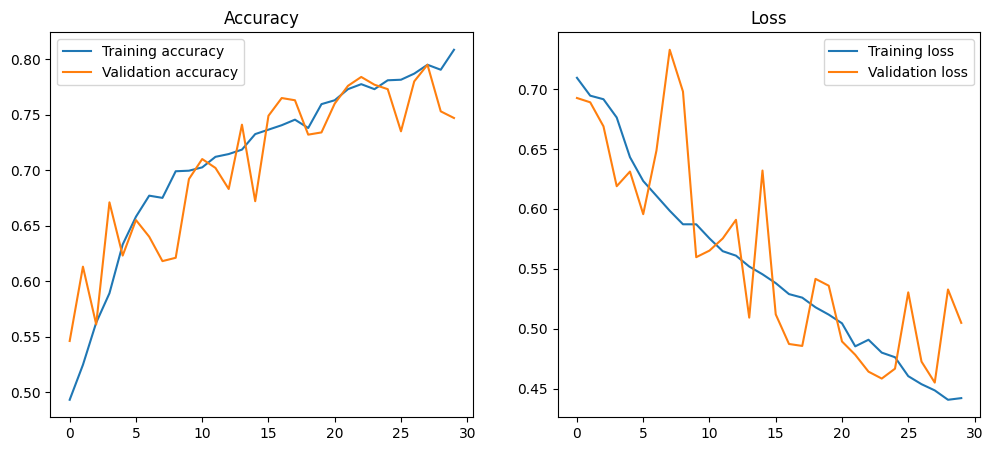

In [ ]:
import matplotlib.pyplot as plt

acc = augmentation.history['accuracy']
val_acc = augmentation.history['val_accuracy']
loss = augmentation.history['loss']
val_loss = augmentation.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training accuracy')
plt.plot(epochs_range, val_acc, label='Validation accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training loss')
plt.plot(epochs_range, val_loss, label='Validation loss')
plt.title('Loss')
plt.legend()

plt.show()

# Part 3 Adding Dropout Layer

A dropout layer is a very simple, yet quite counter-intuitive method. What it does is basically cutting off half of the connection between the layers. You may ask yourself a question - Why do I train the network so hard, only to randomly throw half of the information away? Surprisingly, this works. In many situations network is overfitting to the data so much, that randomly cutting 20%, 30%, or even 50% of connection during training phase will force the other neurons to start working.

To further combat overfitting, we will also add a Dropout layer to our Dogs and Cats example. Add the Dropout layer right before the densely-connected classifier.

In [ ]:
# Implement the model
#...
#model.add(layers.Dropout(0.5))
#...
# Compile and fit the model

model = models.Sequential()

model.add(data_augmentation)

model.add(layers.Rescaling(1./255, input_shape=(150, 150, 3)))
model.add(layers.Conv2D(32, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dropout(0.5))
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

 Wy should expect higher accuracy, about 80-82% compared to 77-80% in the previous task. Plot the results and compare them.

In [ ]:
# plot the results
model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['accuracy'])
augmentation_and_dropout = model.fit(train_dataset, epochs=30, validation_data=val_dataset)


Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 126ms/step - accuracy: 0.5230 - loss: 0.6982 - val_accuracy: 0.5000 - val_loss: 0.7340
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 127ms/step - accuracy: 0.5160 - loss: 0.6946 - val_accuracy: 0.5130 - val_loss: 0.6900
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 111ms/step - accuracy: 0.5660 - loss: 0.6928 - val_accuracy: 0.5500 - val_loss: 0.6764
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 123ms/step - accuracy: 0.6190 - loss: 0.6434 - val_accuracy: 0.5880 - val_loss: 0.6605
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 120ms/step - accuracy: 0.6410 - loss: 0.6481 - val_accuracy: 0.6210 - val_loss: 0.6294
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 116ms/step - accuracy: 0.6650 - loss: 0.6150 - val_accuracy: 0.6940 - val_loss: 0.5774
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 112ms/step - accuracy: 0.6680 - loss: 0.6091 - val_accuracy: 0.6650 - val_loss: 0.6374
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 118ms/step - accuracy: 0.6900 - loss: 0

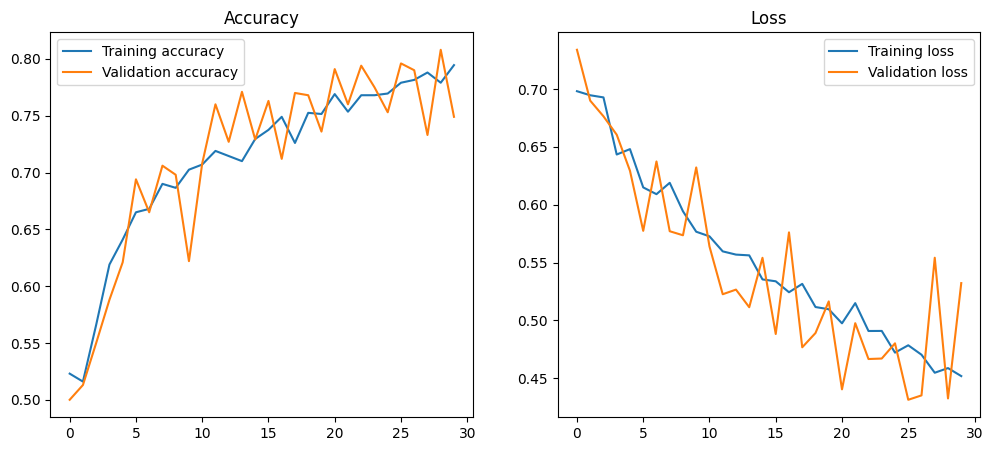

In [ ]:
import matplotlib.pyplot as plt

acc = augmentation_and_dropout.history['accuracy']
val_acc = augmentation_and_dropout.history['val_accuracy']
loss = augmentation_and_dropout.history['loss']
val_loss = augmentation_and_dropout.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training accuracy')
plt.plot(epochs_range, val_acc, label='Validation accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training loss')
plt.plot(epochs_range, val_loss, label='Validation loss')
plt.title('Loss')
plt.legend()

plt.show()

 If you want, you can also try training the model with a dropout layer, but without image augmentation, to see which one is better. Both methods should give better results than training without any of them, but worse than having them combined. Augmentation will improve the model much more than dropout. You may, however, notice, that dropout is faster.

If you want, you can change the dropout parameter. Maybe we cut off too much? You can also try to experiment with putting the dropout layer in different places (maybe between convolutions), or even adding more dropout layers. There is hardly ever one universal way to implement a model. Make some modifications and comment on the results.

# Part 4 Pre-trained Models (Transfer Learning)

A common and highly effective approach to deep learning on small image datasets is to leverage a pre-trained network. A pre-trained network is simply a saved network previously trained on a large dataset. If this original dataset is large enough and general enough, then the spatial feature hierarchy learned by the pre-trained network can effectively act as a generic model of our visual world, and its features can prove useful for many different computer vision problems, even though these new problems might involve completely different classes from those of the original task.

During this exercise we will use the VGG16 architecture, developed by Karen Simonyan and Andrew Zisserman in 2014, a simple and widely used convnet architecture for ImageNet. Some another pre-trained models are VGG, ResNet, Inception, DenseNet, MobileNet, EfficientNet, ConvNeXt.

# Transfer Learning

As we saw previously, convnets used for image classification comprise two parts: they start with a series of pooling and convolution layers, and they end with a densely-connected classifier. The first part is called the “convolutional base” of the model.

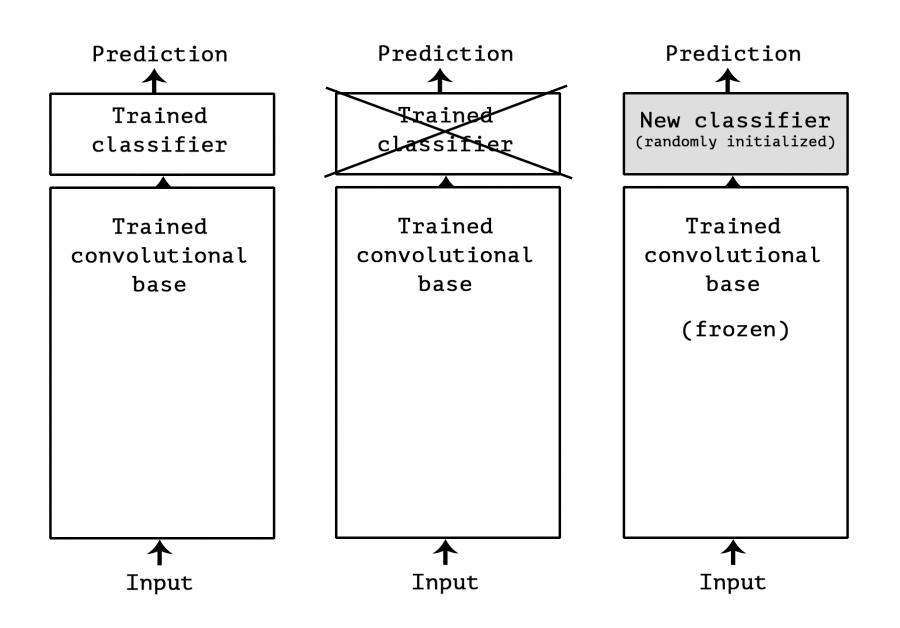

Feature maps of a convnet are maps of generic concepts over a picture. On the other end, the representations learned by the classifier will be very specific to the set of classes that the model was trained on. Additionally, representations found in densely-connected layers no longer contain any information about where objects are located in the input image: these layers get rid of the notion of space.

The VGG16 model, among others, comes pre-packaged with Keras. You can import it from the `keras.applications` module. Here's the list of some image classification models (all pre-trained on the ImageNet dataset) that are available as part of `keras.applications`:

*   VGG16
*   VGG19
*   Xception
*   Inception
*   ResNet
*   DenseNet
*   MobileNet
*   EfficientNet
*   ConvNeXt


# VGG-16 model

Import the model from Keras:

In [ ]:
from tensorflow.keras.applications import VGG16

conv_base = VGG16(weights='imagenet',
                  include_top=False,
                  input_shape=(150, 150, 3))


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


 We passed three arguments to the constructor:

*   weights, to specify which weight checkpoint to initialize the model from
*   include_top, which refers to including or not the densely-connected classifier on top of the network. By default, this densely-connected classifier would correspond to the 1000 classes from ImageNet. Since we intend to use our own densely-connected classifier (with only two classes, cat and dog), we don't need to include it.
*   input_shape, the shape of the image tensors that we will feed to the network. This argument is purely optional: if we don't pass it, then the network will be able to process inputs of any size.


Please analyze the model of VGG-16 (model summary) - after compilation. What is the final feature map shape?

# Pre-trained part as an extended layer

Because models in Keras behave just like layers, you can add a model (like our conv_base) to a Sequential model just like you would add a layer:

In [ ]:
from tensorflow.keras import models
from tensorflow.keras import layers

model = models.Sequential()
model.add(conv_base)
model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

Please analyse the model summary. How many parameters do you have now ? How many parameters are trainable?
Before we compile and train our model, a very important thing to do is to freeze the convolutional base. “Freezing” a layer or set of layers means preventing their weights from getting updated during training. If we don't do this, then the representations that were previously learned by the convolutional base would get modified during training. Since the Dense layers on top are randomly initialized, very large weight updates would be propagated through the network, effectively destroying the representations previously learned.

 In Keras, freezing a network is done by setting its trainable attribute to False:

In [ ]:
print('This is the number of trainable weights '
      'before freezing the conv base:', len(model.trainable_weights))

This is the number of trainable weights before freezing the conv base: 30


In [ ]:
conv_base.trainable = False

print('This is the number of trainable weights '
      'after freezing the conv base:', len(model.trainable_weights))

This is the number of trainable weights after freezing the conv base: 4


With this setup, only the weights from the two Dense layers that we added will be trained. That's a total of four weight tensors: two per layer (the main weight matrix and the bias vector). Note that in order for these changes to take effect, we must first compile the model. If you ever modify weight trainability after compilation, you should then re-compile the model, or these changes would be ignored.

In [ ]:
# Fit the model
# Plot the results

# plot the results
model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['accuracy'])
pre_trained = model.fit(train_dataset, epochs=30, validation_data=val_dataset)


Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 130ms/step - accuracy: 0.8805 - loss: 5.5381 - val_accuracy: 0.8850 - val_loss: 0.4839
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 121ms/step - accuracy: 0.9605 - loss: 0.1767 - val_accuracy: 0.9300 - val_loss: 0.4652
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 121ms/step - accuracy: 0.9760 - loss: 0.1641 - val_accuracy: 0.9190 - val_loss: 0.5893
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 113ms/step - accuracy: 0.9910 - loss: 0.0499 - val_accuracy: 0.9370 - val_loss: 0.5228
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 115ms/step - accuracy: 0.9975 - loss: 0.0125 - val_accuracy: 0.9330 - val_loss: 0.5863
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 120ms/step - accuracy: 0.9955 - loss: 0.0176 - val_accuracy: 0.9410 - val_loss: 0.6298
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 121ms/step - accuracy: 0.9960 - loss: 0.0308 - val_accuracy: 0.9370 - val_loss: 0.9257
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 119ms/step - accuracy: 0.9965 - loss: 0

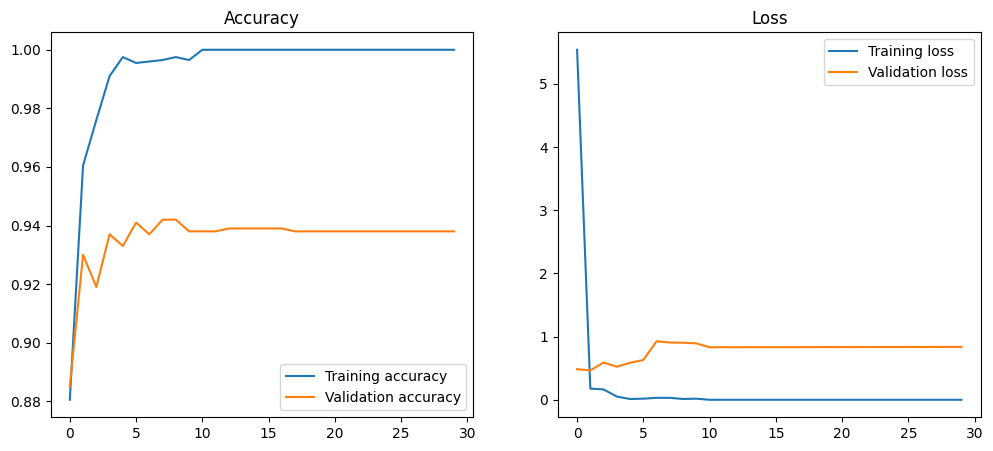

In [ ]:
import matplotlib.pyplot as plt

acc = pre_trained.history['accuracy']
val_acc = pre_trained.history['val_accuracy']
loss = pre_trained.history['loss']
val_loss = pre_trained.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training accuracy')
plt.plot(epochs_range, val_acc, label='Validation accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training loss')
plt.plot(epochs_range, val_loss, label='Validation loss')
plt.title('Loss')
plt.legend()

plt.show()

# Summary

This is the end of the main part of the task, that you need to finish to pass this labs. You should now have results for:


*   Results of training a basic model without any regularisation techniques
*   Results from adding augmentation
*   Results from adding dropout (or both)
*   Results from using a pre-trained model (with or without augmentation and dropout)

As you see, you might have a different combinations of these tools. Please include in your final notebook at least three plots or (if you were saving history of previous trainings) compare them on one plot.

**Please send the completed notebook to the Moodle platform.**

You only send this task, I do not need the MNIST one.

If you finish before the end of the classess, there are two bonus tasks below.



# Bonus Task 1 - Fine-tuning

Another widely used technique for model reuse, complementary to feature extraction, is fine-tuning. Fine-tuning consists of unfreezing a few of the top layers of a frozen model base used for feature extraction, and jointly training both the newly added part of the model.

It is only possible to fine-tune the top layers of the convolutional base once the classifier on top has already been trained. If the classified wasn't already trained, then the error signal propagating through the network during training would be too large, and the representations previously learned by the layers being fine-tuned would be destroyed. Thus the steps for fine-tuning a network are as follow:
1) Add your custom network on top of an already trained base network.
2) Freeze the base network.
3) Train the part you added.
4) Unfreeze some layers in the base network.
5) Train both these layers and the part you added once again.

We have already completed the first 3 steps when doing feature extraction. Let's proceed with the 4th step: we will unfreeze our conv_base, and then freeze individual layers inside of it.

We will fine-tune the last 3 convolutional layers, which means that all layers up until block4_pool should be frozen, and the layers block5_conv1, block5_conv2 and block5_conv3 should be trainable.

Let's set this up, starting from where we left off in the previous example:

In [ ]:
conv_base.trainable = True

set_trainable = False
for layer in conv_base.layers:
    if layer.name == 'block5_conv1':
        set_trainable = True
    if set_trainable:
        layer.trainable = True
    else:
        layer.trainable = False

Now we can start fine-tuning our network. We will do this with the RMSprop optimizer, using a very low learning rate. The reason for using a low learning rate is that we want to limit the magnitude of the modifications we make to the representations of the 3 layers that we are fine-tuning. Updates that are too large may harm these representations.

In [ ]:
from tensorflow.keras import optimizers

model.compile(loss='binary_crossentropy',
              optimizer=optimizers.RMSprop(learning_rate=1e-5),
              metrics=['acc'])

# fit the model for slightly more epochs than before
fine_tuned_pre_trained = model.fit(train_dataset, epochs=30, validation_data=val_dataset)

Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 685s 7s/step - acc: 0.8005 - loss: 1.8339 - val_acc: 0.8750 - val_loss: 0.7655
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 119ms/step - acc: 0.9740 - loss: 0.1167 - val_acc: 0.8890 - val_loss: 0.6966
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 119ms/step - acc: 0.9990 - loss: 0.0032 - val_acc: 0.8970 - val_loss: 0.6870
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 123ms/step - acc: 1.0000 - loss: 6.0810e-05 - val_acc: 0.9010 - val_loss: 0.6686
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 122ms/step - acc: 1.0000 - loss: 9.3434e-06 - val_acc: 0.9010 - val_loss: 0.6677
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 126ms/step - acc: 1.0000 - loss: 6.3226e-06 - val_acc: 0.9010 - val_loss: 0.6674
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 127ms/step - acc: 1.0000 - loss: 4.9613e-06 - val_acc: 0.9020 - val_loss: 0.6671
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 122ms/step - acc: 1.0000 - loss: 4.1305e-06 - val_acc: 0.9020 - val_loss: 0.6669
Epoch 9/30
100

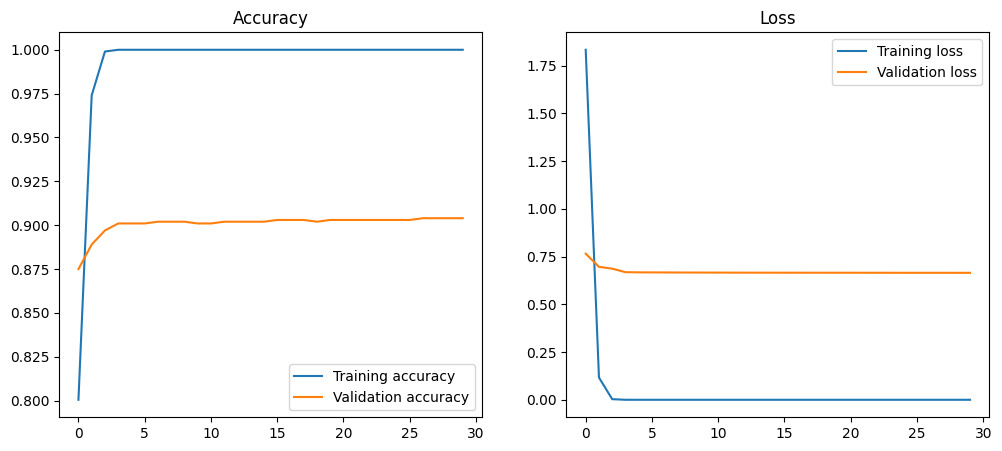

In [ ]:
# plot the results
import matplotlib.pyplot as plt

acc = fine_tuned_pre_trained.history['acc']
val_acc = fine_tuned_pre_trained.history['val_acc']
loss = fine_tuned_pre_trained.history['loss']
val_loss = fine_tuned_pre_trained.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training accuracy')
plt.plot(epochs_range, val_acc, label='Validation accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training loss')
plt.plot(epochs_range, val_loss, label='Validation loss')
plt.title('Loss')
plt.legend()

plt.show()

# Bonus Task 2 - separate feature extraction

You may have noticed, that training the model with a pre-trained feature extraction takes a lot of time. Even though most layers are frozen, data still have to pass though them in each epoch.

In order to save this time, we may split the process into two parts:



1.   Pass all images throgh the feature extractor only once and save the results into another variable (or even save it into a file for later).
2.   Train the classifier with those feature vectors as an input.

This method can save you time and allow many experiments with combinations of different extractors and classifiers. However there is one major drawback - you cannot use data augmentation with this method. If we augment and generate new images in each epoch, they all have to pass through feature extraction every time.



In [ ]:
print(features_train.shape)

(2000, 4, 4, 512)


In [ ]:
features_train = conv_base.predict(train_dataset)
features_train

100/100 ━━━━━━━━━━━━━━━━━━━━ 213s 2s/step


array([[[[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

        [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 4.56196308e-01, 1.03667536e+01],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          3.94215107e+00, 7.34671116e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 5.50665951e+00, ...,
          0.00000000e+00, 0.00000000e+00, 2.17622967e+01],
         [5.52274361e+01, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 1.67778540e+00]],

        [[0.00000000

In [ ]:
import numpy as np

# Pass data through feature extractor:
features_train = []
labels_train = []

for x_batch, y_batch in train_dataset:
    features_batch = conv_base.predict(x_batch)
    features_train.append(features_batch)
    labels_train.append(y_batch)

features_train = np.concatenate(features_train)
labels_train = np.concatenate(labels_train)

features_val = []
labels_val = []

for x_batch, y_batch in val_dataset:
    features_batch = conv_base.predict(x_batch)
    features_val.append(features_batch)
    labels_val.append(y_batch)

features_val = np.concatenate(features_val)
labels_val = np.concatenate(labels_val)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0

In [ ]:
from tensorflow.keras import models
from tensorflow.keras import layers

# ...

# Create a model with a classifier only (Dense layers)

# ...

model_classifier = models.Sequential()
model_classifier.add(layers.Flatten())
model_classifier.add(layers.Dense(256, activation='relu'))
model_classifier.add(layers.Dense(1, activation='sigmoid'))

model_classifier.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])


# Fit the model

history = model_classifier.fit(
    features_train,
    labels_train,
    epochs=30,
    validation_data=(features_val, labels_val)
)

# Analyse the results and see if they are simmilar to the previous approach

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - acc: 0.8745 - loss: 6.8649 - val_acc: 0.9060 - val_loss: 0.5428
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.9610 - loss: 0.2060 - val_acc: 0.9200 - val_loss: 0.5756
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.9875 - loss: 0.0524 - val_acc: 0.9370 - val_loss: 0.3614
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.9845 - loss: 0.0828 - val_acc: 0.9390 - val_loss: 0.5081
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.9925 - loss: 0.0433 - val_acc: 0.9300 - val_loss: 0.9360
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.9910 - loss: 0.1017 - val_acc: 0.9320 - val_loss: 0.9518
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.9985 - loss: 0.0089 - val_acc: 0.9360 - val_loss: 0.7356
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.9935 - loss: 0.0516 - val_acc: 0.9270 - val_loss: 1.1061
Epoch 9/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.9905 - loss:

The results obtained using separate feature extraction are highly consistent with the previous approach, providing nearly identical accuracy while significantly reducing computation time

1. Accuracy: The results are very similar. Previously you achieved a stable 93.8%, and now you have reached 93.6% – 94%. This indicates that the separate feature extraction method did not compromise the model's ability to recognize images.

2. Performance: This is the most significant difference. The training time per epoch dropped from 12–21 seconds to just fractions of a second (5ms/step). Since conv_base.predict was executed only once before training, the CPU/GPU didn't have to process the frozen layers 30 times in a row.

3. Overfitting: The problem remains identical (but with higher loss value for the separate feature extraction solution than for two other solutions). While the model reaches 100% accuracy and a near-zero training loss (2e-08), the validation loss is significantly higher (~0.90) and stops improving after the first few epochs. This gap confirms that the model has simply 'memorized' the training images rather than learning general patterns.


4. Lack of Flexibility: Because the features were extracted only once at the beginning, the model did not benefit from any data augmentation (image distortions). This is why the accuracy plateaued at around 94% and won't go any higher.
